In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from adjustText import adjust_text


__Function for volcano plot__

input: limma output result table

In [22]:
def plot_volcano(
    res_table,
    output,
    string_for_up,
    string_for_down,
    fc_thresh=0.5,
    p_thresh=0.05,
    title="Volcano"
):

    res_df = res_table.copy()

    # ---------------------------
    # Safety checks
    # ---------------------------
    required_cols = ["log2FC", "adj_pvalue", "Protein"]
    for col in required_cols:
        if col not in res_df.columns:
            raise ValueError(f"Missing required column: {col}")

    # ---------------------------
    # Prepare data
    # ---------------------------
    res_df["-log10_p"] = -np.log10(res_df["adj_pvalue"].clip(lower=1e-300))

    # Category assignment
    def categorize(row):
        if row["adj_pvalue"] < p_thresh and row["log2FC"] > fc_thresh:
            return f"Enriched in {string_for_up}"
        elif row["adj_pvalue"] < p_thresh and row["log2FC"] < -fc_thresh:
            return f"Enriched in {string_for_down}"
        else:
            return "Non-significant"

    res_df["category"] = res_df.apply(categorize, axis=1)

    # ---------------------------
    # Titles from limma output
    # ---------------------------
    comparison = res_df["comparison"].iloc[0] if "comparison" in res_df.columns else "Volcano Plot"

    conf = res_df["confounders"].iloc[0] if "confounders" in res_df.columns else ""
    if isinstance(conf, list):
        conf = ", ".join(conf)

    # ---------------------------
    # Plot setup
    # ---------------------------
    palette = {
        f"Enriched in {string_for_up}": "#9ecae1",
        f"Enriched in {string_for_down}": "#fc9272",
        "Non-significant": "#cccccc"
    }

    plt.figure(figsize=(7, 6))

    sns.scatterplot(
        data=res_df,
        x="log2FC",
        y="-log10_p",
        hue="category",
        palette=palette,
        s=50,
        edgecolor="black",
        linewidth=0.3
    )

    # ---------------------------
    # Threshold lines
    # ---------------------------
    plt.axhline(-np.log10(p_thresh), linestyle="--", color="grey")
    plt.axvline(fc_thresh, linestyle="--", color="grey")
    plt.axvline(-fc_thresh, linestyle="--", color="grey")

    plt.xlabel("log2 Fold Change")
    plt.ylabel("-log10(adj. p-value)")

    # ---------------------------
    # Labels (ggrepel-style)
    # ---------------------------
    label_df = res_df[
        (res_df["adj_pvalue"] < p_thresh) &
        (res_df["log2FC"].abs() > fc_thresh)
    ].copy()

    texts = []
    for _, row in label_df.iterrows():
        texts.append(
            plt.text(
                row["log2FC"],
                row["-log10_p"],
                row["Protein"],
                fontsize=7
            )
        )

    adjust_text(
        texts,
        arrowprops=dict(arrowstyle="-", color="black", lw=0.5),
        expand_text=(1.4, 1.6),
        expand_points=(1.2, 1.4),
        force_text=(0.5, 0.8),
        force_points=(0.2, 0.5),
        only_move={"text": "xy"}
    )

    # ---------------------------
    # Titles
    # ---------------------------
    plt.suptitle(title, fontsize=12)
    plt.title(f"Adjusted for: {conf}", fontsize=9)

    plt.legend(title="", loc="upper left")
    plt.tight_layout()

    # ---------------------------
    # Save
    # ---------------------------
    os.makedirs("output/limma_volcano/", exist_ok=True)

    png_path = f"output/limma_volcano/{output}.png"
    pdf_path = f"output/limma_volcano/{output}.pdf"

    plt.savefig(png_path, dpi=300)
    plt.savefig(pdf_path)

    plt.show()

    return png_path, pdf_path

<font color='red'>__Male vs Female (all)__</font>

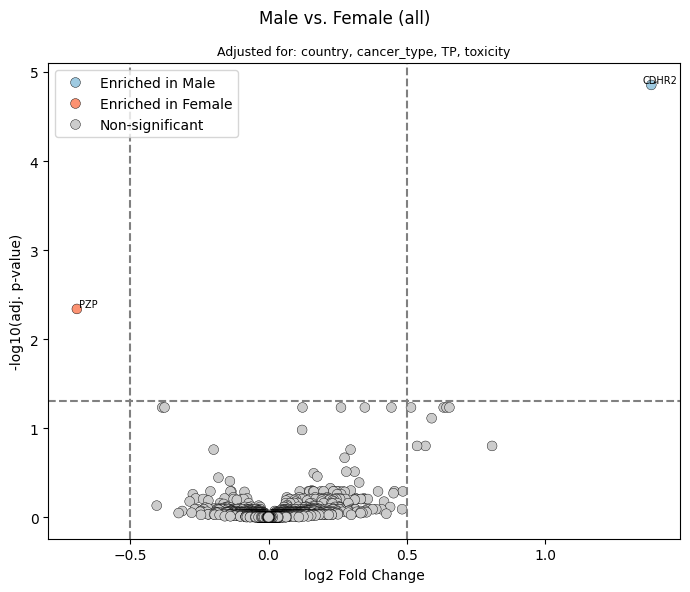

('output/limma_volcano/limma_diff_prot-M_vs_F_all.png',
 'output/limma_volcano/limma_diff_prot-M_vs_F_all.pdf')

In [23]:
m_vs_f_all = pd.read_csv("output/limma/limma_diff_prot-M_vs_F_all.tsv", sep="\t")

plot_volcano(
    res_table=m_vs_f_all, 
    output="limma_diff_prot-M_vs_F_all", 
    string_for_up="Male", 
    string_for_down="Female",
    title="Male vs. Female (all)")

<font color='red'>__Male vs Female (T0, no toxicity)__</font>

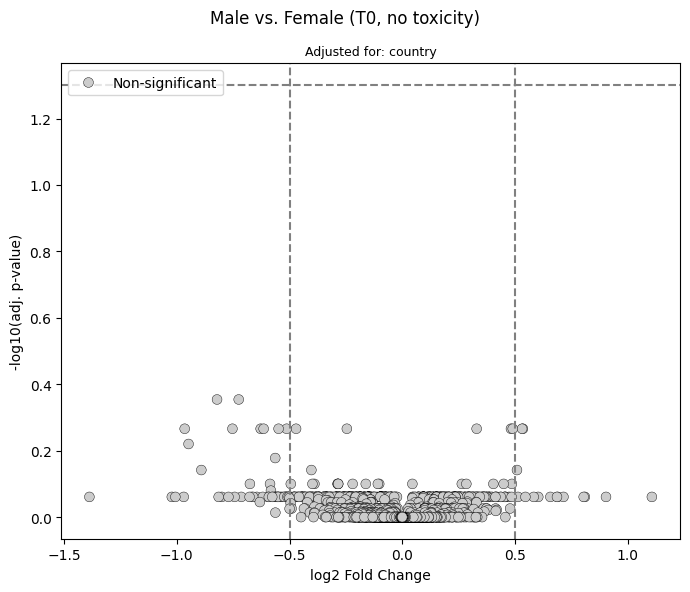

('output/limma_volcano/limma_diff_prot-M_vs_F_T0_notox.png',
 'output/limma_volcano/limma_diff_prot-M_vs_F_T0_notox.pdf')

In [24]:
m_vs_f_t0_notox = pd.read_csv("output/limma/limma_diff_prot-M_vs_F_T0_notox.tsv", sep="\t")

plot_volcano(
    res_table=m_vs_f_t0_notox, 
    output="limma_diff_prot-M_vs_F_T0_notox", 
    string_for_up="Male", 
    string_for_down="Female",
    title="Male vs. Female (T0, no toxicity)")

<font color='red'>__Male vs Female (T0, toxicity)__</font>

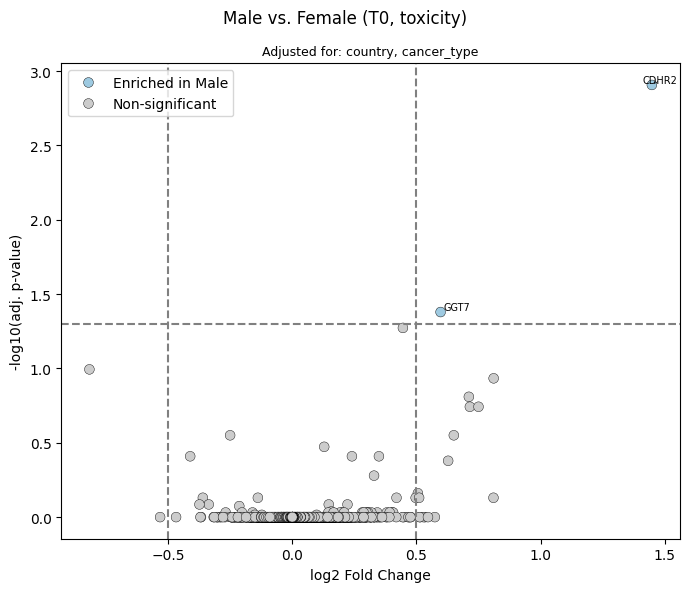

('output/limma_volcano/limma_diff_prot-M_vs_F_T0_tox.png',
 'output/limma_volcano/limma_diff_prot-M_vs_F_T0_tox.pdf')

In [25]:
m_vs_f_t0_tox = pd.read_csv("output/limma/limma_diff_prot-M_vs_F_T0_tox.tsv", sep="\t")

plot_volcano(
    res_table=m_vs_f_t0_tox, 
    output="limma_diff_prot-M_vs_F_T0_tox", 
    string_for_up="Male", 
    string_for_down="Female",
    title="Male vs. Female (T0, toxicity)")

<font color='red'>__T1 vs T0 (all)__</font>

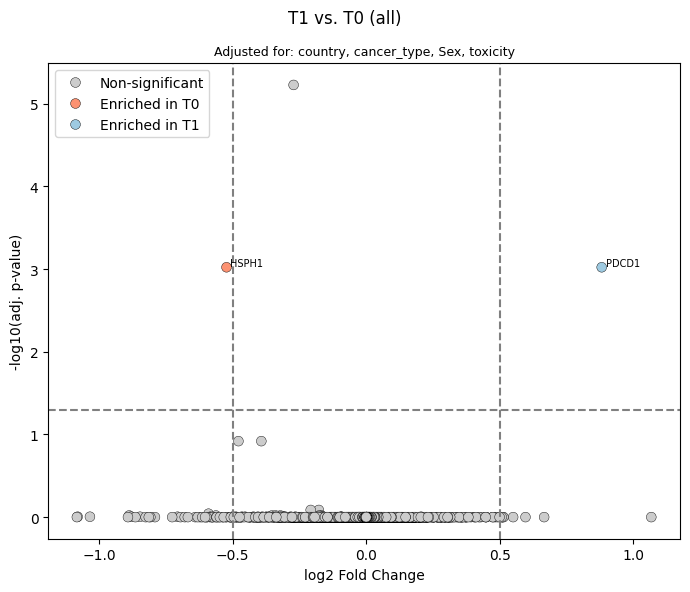

('output/limma_volcano/limma_diff_prot-T1_vs_T0_all.png',
 'output/limma_volcano/limma_diff_prot-T1_vs_T0_all.pdf')

In [26]:
t1_vs_t0_all = pd.read_csv("output/limma/limma_diff_prot-T1_vs_T0_all.tsv", sep="\t")

plot_volcano(
    res_table=t1_vs_t0_all, 
    output="limma_diff_prot-T1_vs_T0_all", 
    string_for_up="T1", 
    string_for_down="T0",
    title="T1 vs. T0 (all)")

<font color='red'>__T1 vs T0 (female)__</font>

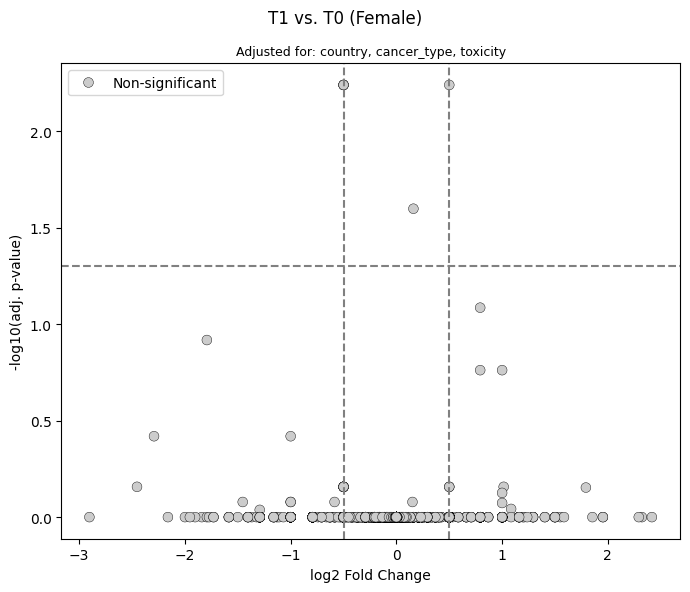

('output/limma_volcano/limma_diff_prot-T1_vs_T0_F.png',
 'output/limma_volcano/limma_diff_prot-T1_vs_T0_F.pdf')

In [27]:
t1_vs_t0_F = pd.read_csv("output/limma/limma_diff_prot-T1_vs_T0_F.tsv", sep="\t")

plot_volcano(
    res_table=t1_vs_t0_F, 
    output="limma_diff_prot-T1_vs_T0_F", 
    string_for_up="T1", 
    string_for_down="T0",
    title="T1 vs. T0 (Female)")

<font color='red'>__T1 vs T0 (male)__</font>

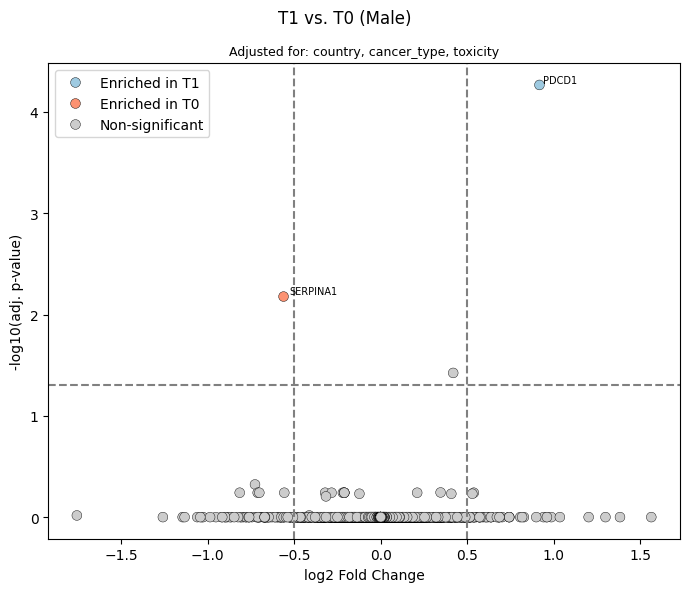

('output/limma_volcano/limma_diff_prot-T1_vs_T0_M.png',
 'output/limma_volcano/limma_diff_prot-T1_vs_T0_M.pdf')

In [28]:
t1_vs_t0_M = pd.read_csv("output/limma/limma_diff_prot-T1_vs_T0_M.tsv", sep="\t")

plot_volcano(
    res_table=t1_vs_t0_M, 
    output="limma_diff_prot-T1_vs_T0_M", 
    string_for_up="T1", 
    string_for_down="T0",
    title="T1 vs. T0 (Male)")

<font color='red'>__T1 vs T0 (no toxicity)__</font>

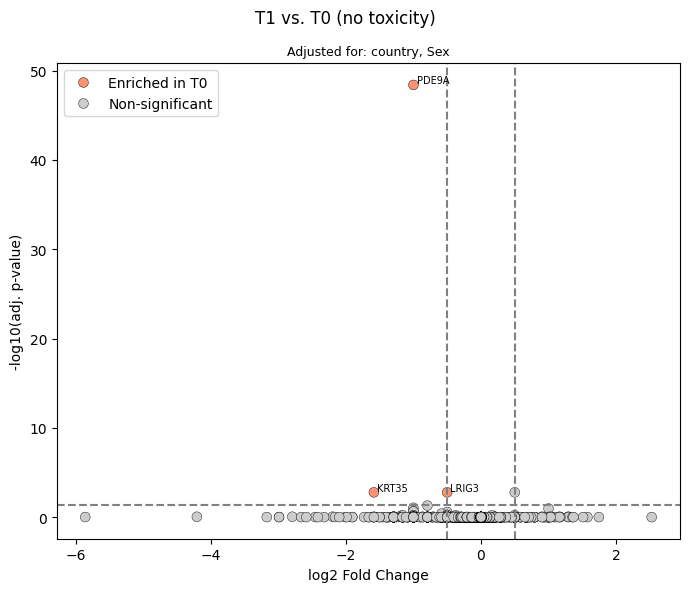

('output/limma_volcano/limma_diff_prot-T1_vs_T0_notox.png',
 'output/limma_volcano/limma_diff_prot-T1_vs_T0_notox.pdf')

In [29]:
t1_vs_t0_notox = pd.read_csv("output/limma/limma_diff_prot-T1_vs_T0_notox.tsv", sep="\t")

plot_volcano(
    res_table=t1_vs_t0_notox, 
    output="limma_diff_prot-T1_vs_T0_notox", 
    string_for_up="T1", 
    string_for_down="T0",
    title="T1 vs. T0 (no toxicity)")

<font color='red'>__T1 vs T0 (toxicity)__</font>

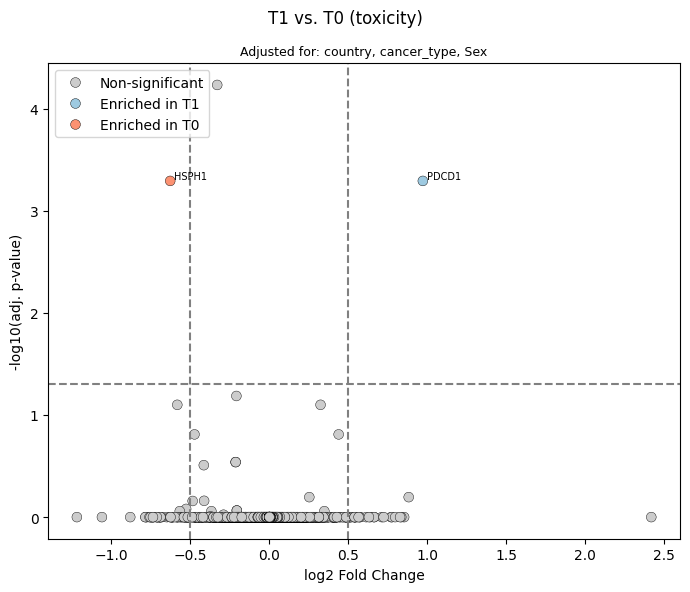

('output/limma_volcano/limma_diff_prot-T1_vs_T0_tox.png',
 'output/limma_volcano/limma_diff_prot-T1_vs_T0_tox.pdf')

In [30]:
t1_vs_t0_tox = pd.read_csv("output/limma/limma_diff_prot-T1_vs_T0_tox.tsv", sep="\t")

plot_volcano(
    res_table=t1_vs_t0_tox, 
    output="limma_diff_prot-T1_vs_T0_tox", 
    string_for_up="T1", 
    string_for_down="T0",
    title="T1 vs. T0 (toxicity)")

<font color='red'>__T2 vs T0 (all)__</font>

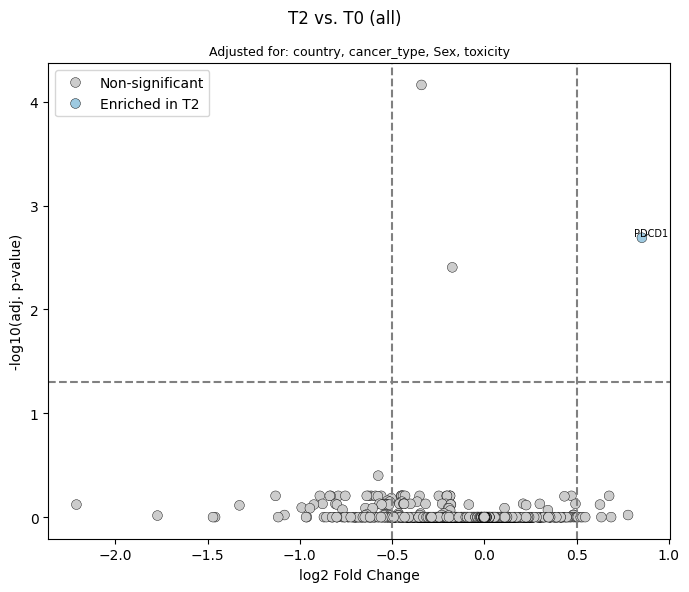

('output/limma_volcano/limma_diff_prot-T2_vs_T0_all.png',
 'output/limma_volcano/limma_diff_prot-T2_vs_T0_all.pdf')

In [31]:
t2_vs_t0_all = pd.read_csv("output/limma/limma_diff_prot-T2_vs_T0_all.tsv", sep="\t")

plot_volcano(
    res_table=t2_vs_t0_all, 
    output="limma_diff_prot-T2_vs_T0_all", 
    string_for_up="T2", 
    string_for_down="T0",
    title="T2 vs. T0 (all)")

<font color='red'>__T2 vs T0 (female toxicity)__</font>

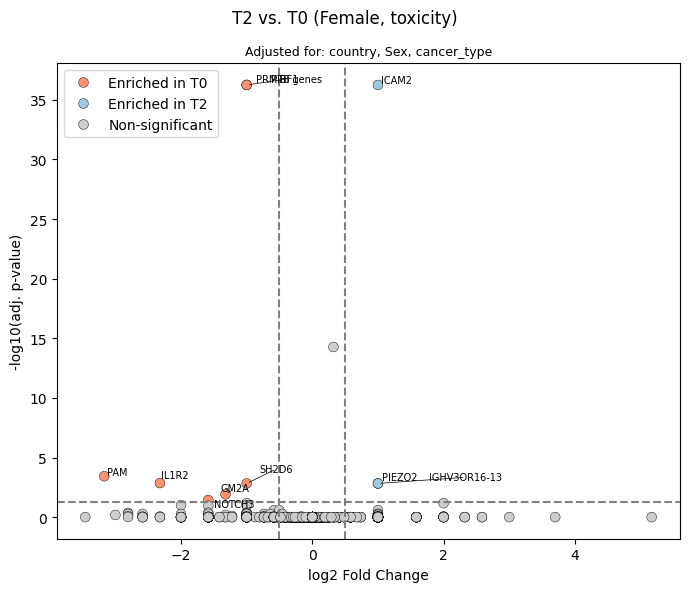

('output/limma_volcano/limma_diff_prot-T2_vs_T0_F_tox.png',
 'output/limma_volcano/limma_diff_prot-T2_vs_T0_F_tox.pdf')

In [32]:
t2_vs_t0_F_tox = pd.read_csv("output/limma/limma_diff_prot-T2_vs_T0_F_tox.tsv", sep="\t")

plot_volcano(
    res_table=t2_vs_t0_F_tox, 
    output="limma_diff_prot-T2_vs_T0_F_tox", 
    string_for_up="T2", 
    string_for_down="T0",
    title="T2 vs. T0 (Female, toxicity)")

<font color='red'>__T2 vs T0 (female)__</font>

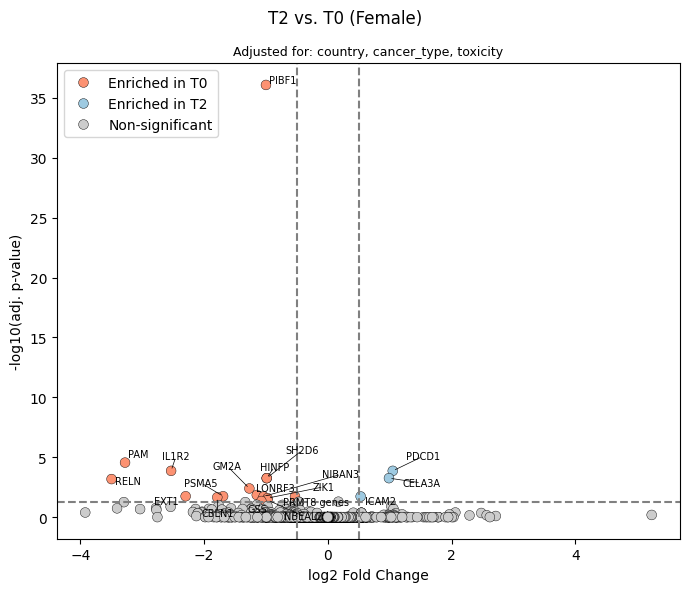

('output/limma_volcano/limma_diff_prot-T2_vs_T0_F.png',
 'output/limma_volcano/limma_diff_prot-T2_vs_T0_F.pdf')

In [33]:
t2_vs_t0_F = pd.read_csv("output/limma/limma_diff_prot-T2_vs_T0_F.tsv", sep="\t")

plot_volcano(
    res_table=t2_vs_t0_F, 
    output="limma_diff_prot-T2_vs_T0_F", 
    string_for_up="T2", 
    string_for_down="T0",
    title="T2 vs. T0 (Female)")

<font color='red'>__T2 vs T0 (male toxicity)__</font>

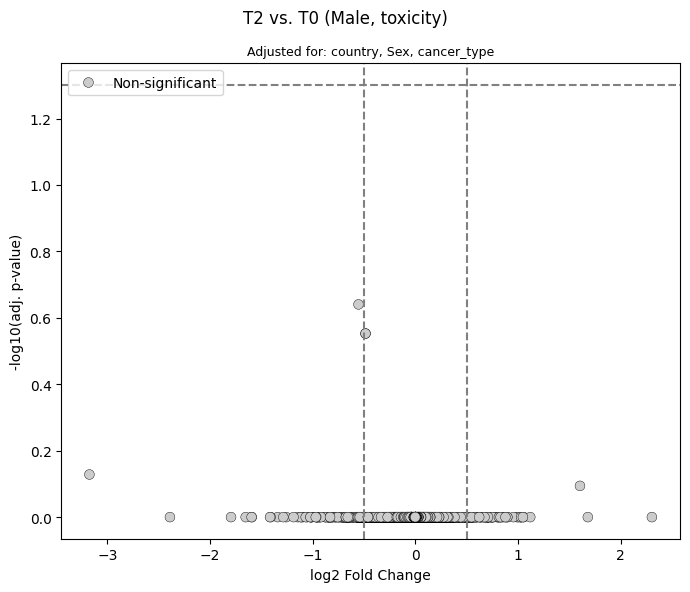

('output/limma_volcano/limma_diff_prot-T2_vs_T0_M_tox.png',
 'output/limma_volcano/limma_diff_prot-T2_vs_T0_M_tox.pdf')

In [34]:
t2_vs_t0_M_tox = pd.read_csv("output/limma/limma_diff_prot-T2_vs_T0_M_tox.tsv", sep="\t")

plot_volcano(
    res_table=t2_vs_t0_M_tox, 
    output="limma_diff_prot-T2_vs_T0_M_tox", 
    string_for_up="T2", 
    string_for_down="T0",
    title="T2 vs. T0 (Male, toxicity)")

<font color='red'>__T2 vs T0 (male)__</font>

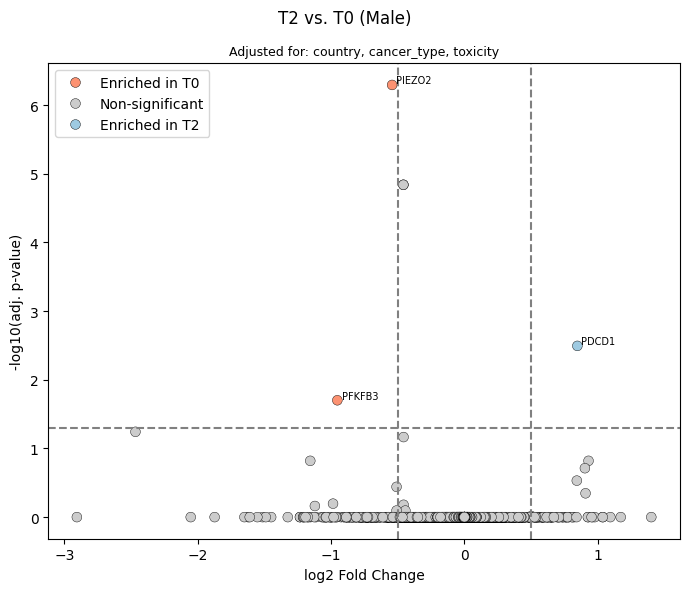

('output/limma_volcano/limma_diff_prot-T2_vs_T0_M.png',
 'output/limma_volcano/limma_diff_prot-T2_vs_T0_M.pdf')

In [35]:
t2_vs_t0_M = pd.read_csv("output/limma/limma_diff_prot-T2_vs_T0_M.tsv", sep="\t")

plot_volcano(
    res_table=t2_vs_t0_M, 
    output="limma_diff_prot-T2_vs_T0_M", 
    string_for_up="T2", 
    string_for_down="T0",
    title="T2 vs. T0 (Male)")

<font color='red'>__toxicity vs no toxicity (T0)__</font>

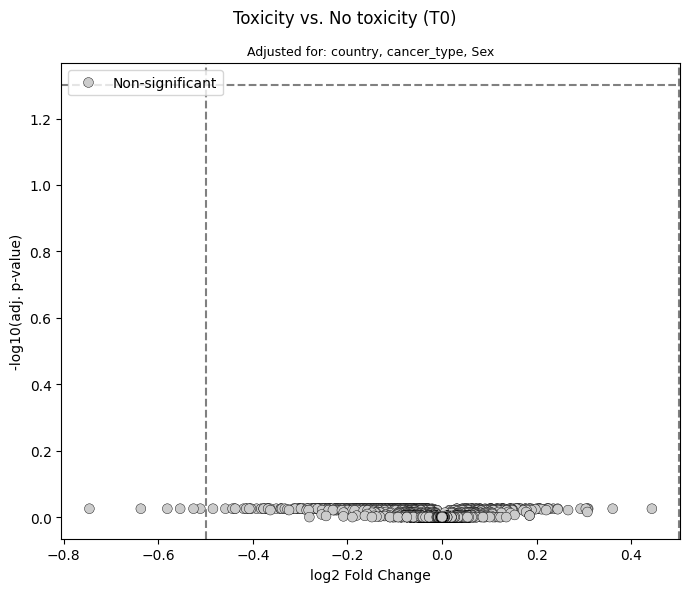

('output/limma_volcano/limma_diff_prot-tox_vs_notox_T0.png',
 'output/limma_volcano/limma_diff_prot-tox_vs_notox_T0.pdf')

In [36]:

tox_vs_notox_T0 = pd.read_csv("output/limma/limma_diff_prot-tox_vs_notox_T0.tsv", sep="\t")

plot_volcano(
    res_table=tox_vs_notox_T0, 
    output="limma_diff_prot-tox_vs_notox_T0", 
    string_for_up="toxicity", 
    string_for_down="no toxicity",
    title="Toxicity vs. No toxicity (T0)")